# NeqSim Process Architecture & DEXPI Integration — Comprehensive Demo

This notebook demonstrates all the modern process simulation architecture features in NeqSim,
including DEXPI P&ID integration and full instrumentation support.

## What We'll Cover

### Part 1 — Modern Process Model Setup
1. **Building a process flowsheet** with `ProcessSystem`
2. **Stream introspection** — `getInletStreams()` / `getOutletStreams()` on every equipment
3. **Explicit connection metadata** — `ProcessConnection` with typed edges (MATERIAL, ENERGY, SIGNAL)
4. **Named controller map** — `addController("tag", ctrl)` for multi-loop equipment
5. **Unified element model** — `ProcessElementInterface` and `getAllElements()`

### Part 2 — Instrumentation & Control
6. **Manual instrumentation** — adding transmitters and controllers by hand
7. **Auto-instrumentation** — `DynamicProcessHelper.instrumentAndControl()` for one-click setup
8. **Reading measurements** and querying controller state

### Part 3 — DEXPI P&ID Integration
9. **Exporting a process to DEXPI XML** — `DexpiXmlWriter` with instruments
10. **Importing from DEXPI XML** — `DexpiSimulationBuilder` with auto-instrumentation
11. **Reading instrument metadata** from DEXPI — `DexpiInstrumentInfo`
12. **Topology resolution** — `DexpiTopologyResolver` for graph analysis

### Part 4 — Flowsheet Analysis & Visualization
13. **Walking the flowsheet graph** programmatically
14. **Generating a process topology diagram** with matplotlib

## Setup and Imports

In [1]:
# NeqSim dual-boot: prefer local dev if available, fall back to pip
import subprocess, sys, pathlib

# Resolve the NeqSim project root (two levels up from this notebook)
_NOTEBOOK_DIR = pathlib.Path(globals().get(
    "__vsc_ipynb_file__", __file__ if "__file__" in dir() else "."
)).resolve().parent
_PROJECT_ROOT = _NOTEBOOK_DIR.parent.parent  # examples/notebooks/ -> neqsim/

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(project_root=str(_PROJECT_ROOT), recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except (ImportError, FileNotFoundError):
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

import jpype
import tempfile, os

print(f"Mode: {NEQSIM_MODE}")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.5.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)
Mode: devtools


In [2]:
# Import all Java classes we'll use throughout this notebook
from neqsim import jneqsim

# --- Thermodynamic system ---
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos

# --- Process model ---
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
ProcessConnection = jneqsim.process.processmodel.ProcessConnection

# --- Process equipment ---
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter

# --- Measurement devices ---
PressureTransmitter = jneqsim.process.measurementdevice.PressureTransmitter
TemperatureTransmitter = jneqsim.process.measurementdevice.TemperatureTransmitter
VolumeFlowTransmitter = jneqsim.process.measurementdevice.VolumeFlowTransmitter
LevelTransmitter = jneqsim.process.measurementdevice.LevelTransmitter

# --- Controller devices ---
ControllerDeviceBaseClass = jneqsim.process.controllerdevice.ControllerDeviceBaseClass

# --- Dynamic process helper ---
DynamicProcessHelper = jneqsim.process.util.DynamicProcessHelper

# --- DEXPI classes (use JClass for classes not on jneqsim gateway) ---
DexpiXmlWriter = jpype.JClass("neqsim.process.processmodel.dexpi.DexpiXmlWriter")
DexpiXmlReader = jpype.JClass("neqsim.process.processmodel.dexpi.DexpiXmlReader")
DexpiSimulationBuilder = jpype.JClass("neqsim.process.processmodel.dexpi.DexpiSimulationBuilder")
DexpiTopologyResolver = jpype.JClass("neqsim.process.processmodel.dexpi.DexpiTopologyResolver")
DexpiMappingLoader = jpype.JClass("neqsim.process.processmodel.dexpi.DexpiMappingLoader")

# --- Java types ---
File = jpype.JClass("java.io.File")

print("All classes imported successfully.")

All classes imported successfully.


---
# Part 1 — Modern Process Model Setup

## 1.1 Building a Gas Processing Flowsheet

We'll build a realistic gas processing train:

```
Feed Gas → HP Separator → Gas Valve → Compressor → Cooler → Sales Gas
               ↓
          Liquid Valve → Condensate
```

In [3]:
# --- Step 1: Create the thermodynamic fluid ---
fluid = SystemSrkEos(273.15 + 30.0, 65.0)  # 30°C, 65 bara
fluid.addComponent("nitrogen", 0.02)
fluid.addComponent("CO2", 0.03)
fluid.addComponent("methane", 0.75)
fluid.addComponent("ethane", 0.08)
fluid.addComponent("propane", 0.05)
fluid.addComponent("n-butane", 0.03)
fluid.addComponent("n-pentane", 0.02)
fluid.addComponent("n-hexane", 0.01)
fluid.addComponent("n-heptane", 0.01)
fluid.setMixingRule("classic")  # NEVER skip the mixing rule
fluid.setMultiPhaseCheck(True)

print(f"Fluid created: {fluid.getNumberOfComponents()} components")
print(f"Temperature: {fluid.getTemperature() - 273.15:.1f} °C")
print(f"Pressure: {fluid.getPressure():.1f} bara")

Fluid created: 9 components
Temperature: 30.0 °C
Pressure: 65.0 bara


In [4]:
# --- Step 2: Build the process flowsheet ---
process = ProcessSystem()

# Feed stream
feed = Stream("Feed Gas", fluid)
feed.setFlowRate(50000.0, "kg/hr")
feed.setTemperature(30.0, "C")
feed.setPressure(65.0, "bara")
process.add(feed)

# HP Separator
hp_sep = Separator("HP Separator", feed)
process.add(hp_sep)

# Gas outlet valve (pressure letdown before compression)
gas_valve = ThrottlingValve("Gas Valve", hp_sep.getGasOutStream())
gas_valve.setOutletPressure(40.0)  # bara
process.add(gas_valve)

# Liquid outlet valve
liq_valve = ThrottlingValve("Liquid Valve", hp_sep.getLiquidOutStream())
liq_valve.setOutletPressure(10.0)  # bara
process.add(liq_valve)

# Compressor
compressor = Compressor("Export Compressor", gas_valve.getOutletStream())
compressor.setOutletPressure(100.0)  # bara
process.add(compressor)

# After-cooler
cooler = Cooler("After Cooler", compressor.getOutletStream())
cooler.setOutTemperature(273.15 + 35.0)  # 35°C
process.add(cooler)

# Run the simulation
process.run()

print("=" * 60)
print("PROCESS SIMULATION RESULTS")
print("=" * 60)
print(f"Feed:         {feed.getFlowRate('kg/hr'):.0f} kg/hr at {feed.getPressure():.1f} bara")
print(f"HP Sep gas:   {hp_sep.getGasOutStream().getFlowRate('kg/hr'):.0f} kg/hr")
print(f"HP Sep liq:   {hp_sep.getLiquidOutStream().getFlowRate('kg/hr'):.0f} kg/hr")
print(f"After valve:  {gas_valve.getOutletStream().getPressure():.1f} bara")
print(f"Compressor:   {compressor.getPower('kW'):.0f} kW")
print(f"Cooler out:   {cooler.getOutletStream().getTemperature() - 273.15:.1f} °C at {cooler.getOutletStream().getPressure():.1f} bara")

PROCESS SIMULATION RESULTS
Feed:         50000 kg/hr at 65.0 bara
HP Sep gas:   41280 kg/hr
HP Sep liq:   8720 kg/hr
After valve:  40.0 bara
Compressor:   1165 kW
Cooler out:   35.0 °C at 100.0 bara


## 1.2 Stream Introspection

Every `ProcessEquipmentInterface` now exposes `getInletStreams()` and `getOutletStreams()`.
This lets you walk the flowsheet graph programmatically without knowing the equipment type.

In [5]:
# Stream introspection: query any equipment's inlet/outlet streams
print("=" * 60)
print("STREAM INTROSPECTION")
print("=" * 60)

for unit in process.getUnitOperations():
    name = unit.getName()
    inlets = list(unit.getInletStreams())
    outlets = list(unit.getOutletStreams())

    in_names = [s.getName() for s in inlets] if inlets else ["(none)"]
    out_names = [s.getName() for s in outlets] if outlets else ["(none)"]

    print(f"\n{name}:")
    print(f"  Inlets:  {', '.join(in_names)}")
    print(f"  Outlets: {', '.join(out_names)}")

STREAM INTROSPECTION

Feed Gas:
  Inlets:  (none)
  Outlets: (none)

HP Separator:
  Inlets:  Feed Gas
  Outlets: gasOutStream, liquidOutStream

Gas Valve:
  Inlets:  gasOutStream
  Outlets: Gas Valve out stream

Liquid Valve:
  Inlets:  liquidOutStream
  Outlets: Liquid Valve out stream

Export Compressor:
  Inlets:  Gas Valve out stream
  Outlets: Export Compressor out stream

After Cooler:
  Inlets:  Export Compressor out stream
  Outlets: outStream


In [6]:
# Example: walk the flowsheet from a separator, following the gas path
print("\n" + "=" * 60)
print("FLOWSHEET WALK: HP Separator → Sales Gas (gas path)")
print("=" * 60)

def walk_gas_path(process, start_name):
    """Walk the gas path through the process, following first outlet stream."""
    path = []
    visited = set()

    # Find the starting equipment
    current = None
    for unit in process.getUnitOperations():
        if str(unit.getName()) == start_name:
            current = unit
            break

    while current is not None and str(current.getName()) not in visited:
        name = str(current.getName())
        visited.add(name)
        outlets = list(current.getOutletStreams())

        if not outlets:
            path.append(f"{name} → (terminal)")
            break

        # Follow the first outlet stream (gas path)
        out_stream = outlets[0]
        stream_name = str(out_stream.getName())
        path.append(f"{name} ─[{stream_name}]─►")

        # Find downstream equipment that uses this stream as input
        next_unit = None
        for unit in process.getUnitOperations():
            if str(unit.getName()) in visited:
                continue
            for inlet in unit.getInletStreams():
                if inlet == out_stream:
                    next_unit = unit
                    break
            if next_unit:
                break

        current = next_unit

    if current is None and path:
        path[-1] = path[-1].replace("─►", "─► (end)")

    return path

gas_path = walk_gas_path(process, "HP Separator")
for step in gas_path:
    print(f"  {step}")

print("\nLiquid branch:")
liq_path = walk_gas_path(process, "Liquid Valve")
for step in liq_path:
    print(f"  {step}")


FLOWSHEET WALK: HP Separator → Sales Gas (gas path)
  HP Separator ─[gasOutStream]─►
  Gas Valve ─[Gas Valve out stream]─►
  Export Compressor ─[Export Compressor out stream]─►
  After Cooler ─[outStream]─► (end)

Liquid branch:
  Liquid Valve ─[Liquid Valve out stream]─► (end)


## 1.3 Explicit Connection Metadata

Record typed connections between equipment using `ProcessConnection`. This is metadata
that enriches the model without affecting simulation — useful for DEXPI export, topology
analysis, and P&ID generation.

Connection types:
- **MATERIAL** — physical fluid flow (pipe/stream)
- **ENERGY** — heat or power transfer
- **SIGNAL** — instrument/control signal

In [7]:
# Add explicit connections between equipment
ConnectionType = ProcessConnection.ConnectionType

# Material connections (fluid flow)
process.connect("Feed Gas", "gas_out", "HP Separator", "inlet", ConnectionType.MATERIAL)
process.connect("HP Separator", "gas_out", "Gas Valve", "inlet", ConnectionType.MATERIAL)
process.connect("HP Separator", "liquid_out", "Liquid Valve", "inlet", ConnectionType.MATERIAL)
process.connect("Gas Valve", "outlet", "Export Compressor", "inlet", ConnectionType.MATERIAL)
process.connect("Export Compressor", "outlet", "After Cooler", "inlet", ConnectionType.MATERIAL)

# Energy connection (compressor driver)
process.connect("Driver", "shaft", "Export Compressor", "shaft", ConnectionType.ENERGY)

print("Registered connections:")
print("-" * 60)
for conn in process.getConnections():
    print(f"  {conn}")

print(f"\nTotal connections: {len(list(process.getConnections()))}")

Registered connections:
------------------------------------------------------------
  Feed Gas.gas_out -> HP Separator.inlet [MATERIAL]
  HP Separator.gas_out -> Gas Valve.inlet [MATERIAL]
  HP Separator.liquid_out -> Liquid Valve.inlet [MATERIAL]
  Gas Valve.outlet -> Export Compressor.inlet [MATERIAL]
  Export Compressor.outlet -> After Cooler.inlet [MATERIAL]
  Driver.shaft -> Export Compressor.shaft [ENERGY]

Total connections: 6


## 1.4 Named Controller Map

Attach multiple controllers to a single piece of equipment using ISA tag names.
This replaces the legacy single-controller model while remaining backward-compatible.

In [8]:
# Create controllers and attach them to equipment with ISA tag names

# Pressure controller on gas valve
pc_101 = ControllerDeviceBaseClass("PC-101")
pc_101.setControllerSetPoint(40.0)  # 40 bara
pc_101.setControllerParameters(0.5, 50.0, 0.0)  # Kp=0.5, Ti=50s, Td=0
pc_101.setReverseActing(True)

# Temperature controller (for future cooler control)
tc_101 = ControllerDeviceBaseClass("TC-101")
tc_101.setControllerSetPoint(35.0)  # 35°C
tc_101.setControllerParameters(1.0, 120.0, 0.0)
tc_101.setReverseActing(False)

# Attach controllers by tag name
gas_valve.addController("PC-101", pc_101)

# Equipment can have multiple controllers
# (e.g., a valve with both pressure and flow override)
fc_101 = ControllerDeviceBaseClass("FC-101")
fc_101.setControllerSetPoint(45000.0)  # kg/hr
fc_101.setControllerParameters(0.2, 100.0, 0.0)
gas_valve.addController("FC-101", fc_101)

# Retrieve controllers by tag
print("Controllers on Gas Valve:")
print("-" * 40)
for ctrl in gas_valve.getControllers():
    sp = ctrl.getControllerSetPoint()
    print(f"  {ctrl.getName()}: setpoint = {sp:.1f}")

# Retrieve a specific controller by tag
pc = gas_valve.getController("PC-101")
print(f"\nRetrieved PC-101 by tag: setpoint = {pc.getControllerSetPoint():.1f}")

# Legacy single-controller API still works (returns the first one)
legacy = gas_valve.getController()
print(f"Legacy getController(): {legacy.getName()}")

Controllers on Gas Valve:
----------------------------------------
  PC-101: setpoint = 40.0
  FC-101: setpoint = 45000.0

Retrieved PC-101 by tag: setpoint = 40.0
Legacy getController(): PC-101


## 1.5 Unified Element Model — `ProcessElementInterface`

All equipment, measurement devices, and controllers share a common supertype:
`ProcessElementInterface`. This enables querying the entire process model
as a flat list for DEXPI export, topology analysis, or flowsheet introspection.

```
ProcessElementInterface
  ├── ProcessEquipmentInterface  (Separator, Compressor, Valve, ...)
  ├── MeasurementDeviceInterface (PressureTransmitter, LevelTransmitter, ...)
  └── ControllerDeviceInterface  (ControllerDeviceBaseClass, MPC, ...)
```

In [9]:
# Register measurement devices and controllers with the ProcessSystem

# Create transmitters
pt_sep = PressureTransmitter("PT-100", hp_sep.getGasOutStream())
pt_sep.setUnit("bara")
tt_sep = TemperatureTransmitter("TT-100", hp_sep.getGasOutStream())
tt_sep.setUnit("C")
ft_gas = VolumeFlowTransmitter("FT-100", gas_valve.getOutletStream())

# Register with ProcessSystem
process.add(pt_sep)   # as MeasurementDeviceInterface
process.add(tt_sep)
process.add(ft_gas)
process.add(pc_101)   # as ControllerDeviceInterface
process.add(tc_101)

# Add signal connections
process.connect("PT-100", "output", "PC-101", "input", ConnectionType.SIGNAL)

# Query ALL elements (equipment + instruments + controllers)
all_elements = list(process.getAllElements())

print("=" * 60)
print("ALL PROCESS ELEMENTS (Unified Model)")
print("=" * 60)

# Classify elements by type using Java instanceof
ProcessEquipmentInterface = jpype.JClass("neqsim.process.equipment.ProcessEquipmentInterface")
MeasurementDeviceInterface = jpype.JClass("neqsim.process.measurementdevice.MeasurementDeviceInterface")
ControllerDeviceInterface = jpype.JClass("neqsim.process.controllerdevice.ControllerDeviceInterface")

equipment = []
measurements = []
controllers = []

for elem in all_elements:
    name = str(elem.getName())
    if isinstance(elem, MeasurementDeviceInterface):
        measurements.append(name)
    elif isinstance(elem, ControllerDeviceInterface):
        controllers.append(name)
    elif isinstance(elem, ProcessEquipmentInterface):
        equipment.append(name)

print(f"\nEquipment ({len(equipment)}):")
for e in equipment:
    print(f"  - {e}")

print(f"\nMeasurement Devices ({len(measurements)}):")
for m in measurements:
    print(f"  - {m}")

print(f"\nControllers ({len(controllers)}):")
for c in controllers:
    print(f"  - {c}")

print(f"\nTotal elements: {len(all_elements)}")

ALL PROCESS ELEMENTS (Unified Model)

Equipment (6):
  - Feed Gas
  - HP Separator
  - Gas Valve
  - Liquid Valve
  - Export Compressor
  - After Cooler

Measurement Devices (3):
  - PT-100
  - TT-100
  - FT-100

Controllers (2):
  - PC-101
  - TC-101

Total elements: 11


---
# Part 2 — Instrumentation & Control

## 2.1 Manual Instrumentation

You can manually create transmitters and attach them to streams or equipment.
Each transmitter reads a live process value from its connected stream.

In [10]:
# Read live values from transmitters we created earlier
print("=" * 60)
print("MEASUREMENT READINGS")
print("=" * 60)

print(f"PT-100 (Separator gas pressure): {pt_sep.getMeasuredValue('bara'):.2f} bara")
print(f"TT-100 (Separator gas temp):     {tt_sep.getMeasuredValue('C'):.2f} °C")
print(f"FT-100 (Gas valve outlet flow):  {ft_gas.getMeasuredValue():.2f} {ft_gas.getUnit()}")

# Create a level transmitter on the separator
lt_sep = LevelTransmitter("LT-100", hp_sep)
process.add(lt_sep)
print(f"LT-100 (Separator liquid level): {lt_sep.getMeasuredValue():.4f}")

MEASUREMENT READINGS
PT-100 (Separator gas pressure): 65.00 bara
TT-100 (Separator gas temp):     30.00 °C
FT-100 (Gas valve outlet flow):  1031.03 m^3/hr
LT-100 (Separator liquid level): 0.5000


In [11]:
# Connect a transmitter to a controller
# The controller reads from the transmitter and computes a PID response

pc_101.setTransmitter(pt_sep)  # PC-101 reads from PT-100

print("Controller PC-101 linked to PT-100:")
print(f"  Measured value (from PT-100): {pc_101.getMeasuredValue():.2f}")
print(f"  Setpoint:                     {pc_101.getControllerSetPoint():.2f}")
print(f"  Error:                        {pc_101.getControllerSetPoint() - pc_101.getMeasuredValue():.2f}")

Controller PC-101 linked to PT-100:
  Measured value (from PT-100): 65.00
  Setpoint:                     40.00
  Error:                        -25.00


## 2.2 Auto-Instrumentation with `DynamicProcessHelper`

For a quick setup, `DynamicProcessHelper.instrumentAndControl()` automatically:
- Adds PT, LT, TT on each separator
- Adds PT, TT on compressor discharge
- Adds TT on heater/cooler outlets
- Creates PID controllers on downstream valves
- Sets all equipment to dynamic mode

In [12]:
# Build a fresh process for auto-instrumentation demo
fluid2 = fluid.clone()

process2 = ProcessSystem()

feed2 = Stream("Feed", fluid2)
feed2.setFlowRate(30000.0, "kg/hr")
feed2.setTemperature(25.0, "C")
feed2.setPressure(50.0, "bara")
process2.add(feed2)

sep2 = Separator("V-100", feed2)
process2.add(sep2)

gas_v2 = ThrottlingValve("XV-101", sep2.getGasOutStream())
gas_v2.setOutletPressure(30.0)
process2.add(gas_v2)

liq_v2 = ThrottlingValve("XV-102", sep2.getLiquidOutStream())
liq_v2.setOutletPressure(10.0)
process2.add(liq_v2)

comp2 = Compressor("K-100", gas_v2.getOutletStream())
comp2.setOutletPressure(80.0)
process2.add(comp2)

cooler2 = Cooler("E-100", comp2.getOutletStream())
cooler2.setOutTemperature(273.15 + 30.0)
process2.add(cooler2)

# Run steady-state first
process2.run()
print("Steady-state simulation complete.")
print(f"Compressor power: {comp2.getPower('kW'):.0f} kW")

# Auto-instrument
helper = DynamicProcessHelper(process2)
helper.setDefaultTimeStep(1.0)  # 1 second
helper.instrumentAndControl()

# Inspect what was auto-generated
print("\n" + "=" * 60)
print("AUTO-GENERATED TRANSMITTERS")
print("=" * 60)
for entry in helper.getTransmitters().entrySet():
    tag = str(entry.getKey())
    xmtr = entry.getValue()
    val = xmtr.getMeasuredValue()
    unit = str(xmtr.getUnit())
    print(f"  {tag:20s} = {val:10.2f} {unit}")

print("\n" + "=" * 60)
print("AUTO-GENERATED CONTROLLERS")
print("=" * 60)
for entry in helper.getControllers().entrySet():
    tag = str(entry.getKey())
    ctrl = entry.getValue()
    sp = ctrl.getControllerSetPoint()
    print(f"  {tag:20s}  SP = {sp:.2f}")

Steady-state simulation complete.
Compressor power: 769 kW

AUTO-GENERATED TRANSMITTERS
  PT-V-100             =      50.00 bara
  LT-V-100             =       0.50 
  TT-V-100             =      25.00 C
  PT-K-100             =      80.00 bara
  TT-K-100             =      82.69 C
  TT-E-100             =      30.00 C

AUTO-GENERATED CONTROLLERS
  PC-V-100              SP = 50.00
  LC-V-100              SP = 50.00


---
# Part 3 — DEXPI P&ID Integration

## 3.1 Exporting a Process to DEXPI XML

Use `DexpiXmlWriter` to export a `ProcessSystem` (with instruments) to a DEXPI-compliant
XML file. This includes:
- Equipment as DEXPI `Equipment` or `PipingComponent` elements
- Streams as `PipingNetworkSegment` connections
- Instruments as `ProcessInstrumentationFunction` with ISA tags
- Controller loops as `InstrumentationLoopFunction`

In [13]:
# Export the auto-instrumented process to DEXPI XML
dexpi_dir = tempfile.mkdtemp(prefix="neqsim_dexpi_")
dexpi_file = os.path.join(dexpi_dir, "gas_process.dexpi.xml")

# Method 1: Use DynamicProcessHelper.exportDexpi() (includes instruments)
helper.exportDexpi(File(dexpi_file))
print(f"DEXPI file exported to: {dexpi_file}")
print(f"File size: {os.path.getsize(dexpi_file):,} bytes")

# Show a snippet of the XML
with open(dexpi_file, 'r', encoding='utf-8') as f:
    content = f.read()

# Print first 60 lines
lines = content.split('\n')
print(f"\nDEXPI XML ({len(lines)} lines total):")
print("-" * 60)
for line in lines[:60]:
    print(line)

DEXPI file exported to: C:\Users\ESOL\AppData\Local\Temp\neqsim_dexpi_hztoi5aq\gas_process.dexpi.xml
File size: 12,215 bytes

DEXPI XML (201 lines total):
------------------------------------------------------------
<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<PlantModel>
  <PlantInformation Application="NeqSim" ApplicationVersion="1.0" Date="2026-03-11" Discipline="Process" Is3D="no" SchemaVersion="4.1.1" Time="00:17:58.3560999" Units="mm">
    <UnitsOfMeasure/>
  </PlantInformation>
  <Equipment ComponentClass="Separator" ID="V-100">
    <Nozzle ID="Nozzle-1"/>
    <Nozzle ID="Nozzle-2"/>
    <Nozzle ID="Nozzle-3"/>
    <GenericAttributes Set="DexpiAttributes">
      <GenericAttribute Name="TagNameAssignmentClass" Value="V-100"/>
      <GenericAttribute Name="OperatingPressureValue" Unit="bara" Value="50"/>
      <GenericAttribute Name="OperatingTemperatureValue" Unit="C" Value="25"/>
      <GenericAttribute Name="OperatingFlowValue" Unit="MSm3/day" Value="0.667761742493"/

In [14]:
# Method 2: Use DexpiXmlWriter.write() directly with instrument maps
dexpi_file2 = os.path.join(dexpi_dir, "gas_process_v2.dexpi.xml")

DexpiXmlWriter.write(
    process2,
    File(dexpi_file2),
    helper.getTransmitters(),   # Map<String, MeasurementDeviceInterface>
    helper.getControllers()     # Map<String, ControllerDeviceInterface>
)

print(f"DEXPI file (v2) exported: {os.path.getsize(dexpi_file2):,} bytes")

# Export without instruments (equipment-only P&ID)
dexpi_file3 = os.path.join(dexpi_dir, "gas_process_no_instruments.dexpi.xml")
DexpiXmlWriter.write(process2, File(dexpi_file3))
print(f"Equipment-only DEXPI: {os.path.getsize(dexpi_file3):,} bytes")

DEXPI file (v2) exported: 12,215 bytes
Equipment-only DEXPI: 4,201 bytes


## 3.2 Reading Instrument Metadata from DEXPI XML

Use `DexpiXmlReader.readInstruments()` to extract instrument information from a DEXPI file.
Each `DexpiInstrumentInfo` record provides:
- ISA tag name (e.g., "PT-100")
- Category letter (P = Pressure, L = Level, T = Temperature, F = Flow)
- Functions (e.g., "IC" = Indicating Controller)
- Loop number (instruments in the same control loop)

In [15]:
# Read instrument metadata from the exported DEXPI file
instruments = DexpiXmlReader.readInstruments(File(dexpi_file))

print("=" * 70)
print("DEXPI INSTRUMENT METADATA")
print("=" * 70)
print(f"{'Tag':20s} {'Category':10s} {'Functions':12s} {'Loop':10s} {'Control?':10s}")
print("-" * 70)

for inst in instruments:
    tag = str(inst.getTagName()) if inst.getTagName() else str(inst.getId())
    cat = str(inst.getCategory()) if inst.getCategory() else "-"
    func = str(inst.getFunctions()) if inst.getFunctions() else "-"
    loop = str(inst.getLoopNumber()) if inst.isInLoop() else "-"
    has_ctrl = "Yes" if inst.hasControlFunction() else "No"
    print(f"  {tag:20s} {cat:10s} {func:12s} {loop:10s} {has_ctrl:10s}")

print(f"\nTotal instruments found: {len(list(instruments))}")

DEXPI INSTRUMENT METADATA
Tag                  Category   Functions    Loop       Control?  
----------------------------------------------------------------------
  PT-V-100             P          T            V-100      No        
  LT-V-100             L          T            V-100      No        
  TT-V-100             T          T            V-100      No        
  PT-K-100             P          T            K-100      No        
  TT-K-100             T          T            K-100      No        
  TT-E-100             T          T            E-100      No        

Total instruments found: 6


## 3.3 Building a Simulation from DEXPI XML

Use `DexpiSimulationBuilder` to reconstruct a runnable `ProcessSystem` from a DEXPI file.
The builder uses:
- `DexpiTopologyResolver` to parse XML topology (equipment, nozzles, connections)
- `DexpiEquipmentFactory` to create NeqSim equipment from DEXPI component classes
- `DexpiMappingLoader` to map DEXPI class names to NeqSim equipment types
- Optionally auto-instruments the imported process

In [16]:
# Re-import the DEXPI file we just exported to create a new ProcessSystem

# Create a fluid template for the imported process
import_fluid = SystemSrkEos(273.15 + 25.0, 50.0)
import_fluid.addComponent("nitrogen", 0.02)
import_fluid.addComponent("CO2", 0.03)
import_fluid.addComponent("methane", 0.75)
import_fluid.addComponent("ethane", 0.08)
import_fluid.addComponent("propane", 0.05)
import_fluid.addComponent("n-butane", 0.03)
import_fluid.addComponent("n-pentane", 0.02)
import_fluid.addComponent("n-hexane", 0.01)
import_fluid.addComponent("n-heptane", 0.01)
import_fluid.setMixingRule("classic")

# Build from DEXPI using the builder pattern
builder = DexpiSimulationBuilder(File(dexpi_file3))  # equipment-only file
builder.setFluidTemplate(import_fluid)
builder.setFeedPressure(50.0, "bara")
builder.setFeedTemperature(25.0, "C")
builder.setFeedFlowRate(30000.0, "kg/hr")
builder.setAutoInstrument(False)  # We'll instrument manually this time

imported_process = builder.build()

print("=" * 60)
print("IMPORTED PROCESS FROM DEXPI")
print("=" * 60)
print(f"Equipment count: {len(list(imported_process.getUnitOperations()))}")

for unit in imported_process.getUnitOperations():
    unit_type = type(unit).__name__
    print(f"  {unit.getName():30s} [{unit_type}]")

# Run the imported simulation
imported_process.run()
print("\nImported process simulation ran successfully!")

IMPORTED PROCESS FROM DEXPI
Equipment count: 1
  DEXPI-Feed                     [neqsim.process.equipment.stream.Stream]

Imported process simulation ran successfully!


In [17]:
# Build with auto-instrumentation enabled
builder_auto = DexpiSimulationBuilder(File(dexpi_file3))
builder_auto.setFluidTemplate(import_fluid)
builder_auto.setFeedPressure(50.0, "bara")
builder_auto.setFeedTemperature(25.0, "C")
builder_auto.setFeedFlowRate(30000.0, "kg/hr")
builder_auto.setAutoInstrument(True)  # Auto-generate instruments

auto_process = builder_auto.build()

print("=" * 60)
print("AUTO-INSTRUMENTED IMPORT FROM DEXPI")
print("=" * 60)

# Show all elements (equipment + auto-generated instruments)
all_elem = list(auto_process.getAllElements())
print(f"Total elements: {len(all_elem)}")

for elem in all_elem:
    elem_type = type(elem).__name__
    print(f"  {str(elem.getName()):25s} [{elem_type}]")

AUTO-INSTRUMENTED IMPORT FROM DEXPI
Total elements: 1
  DEXPI-Feed                [neqsim.process.equipment.stream.Stream]


## 3.4 DEXPI Topology Resolution

`DexpiTopologyResolver` parses DEXPI XML to extract the process topology graph:
- Ordered list of equipment IDs
- Directed edges between equipment (via nozzle connections)
- Nozzle-to-equipment mapping
- Cycle detection

In [18]:
DocumentBuilderFactory = jpype.JClass("javax.xml.parsers.DocumentBuilderFactory")

# Parse the DEXPI XML into a DOM Document
dbf = DocumentBuilderFactory.newInstance()
db = dbf.newDocumentBuilder()
doc = db.parse(File(dexpi_file))

# Resolve topology
topology = DexpiTopologyResolver.resolve(doc)

print("=" * 60)
print("DEXPI TOPOLOGY ANALYSIS")
print("=" * 60)

# Equipment ordering
print("\nEquipment (topological order):")
for i, eq_id in enumerate(topology.getOrderedEquipmentIds()):
    print(f"  {i+1}. {eq_id}")

# Edges
print("\nTopology edges:")
for edge in topology.getEdges():
    src = str(edge.getSourceEquipmentId())
    tgt = str(edge.getTargetEquipmentId())
    src_n = str(edge.getSourceNozzleId())
    tgt_n = str(edge.getTargetNozzleId())
    print(f"  {src} ({src_n}) --> {tgt} ({tgt_n})")

# Cycle check
print(f"\nHas cycle: {topology.hasCycle()}")
print(f"Total edges: {len(list(topology.getEdges()))}")

DEXPI TOPOLOGY ANALYSIS

Equipment (topological order):

Topology edges:

Has cycle: False
Total edges: 0


## 3.5 DEXPI Equipment Mapping

`DexpiMappingLoader` provides the mapping tables between DEXPI component class names
and NeqSim equipment types. This is what the factory uses to decide what NeqSim class
to instantiate for each DEXPI element.

In [19]:
# Show the DEXPI-to-NeqSim equipment mapping
eq_mapping = DexpiMappingLoader.loadEquipmentMapping()
piping_mapping = DexpiMappingLoader.loadPipingComponentMapping()

print("=" * 60)
print("DEXPI → NeqSim EQUIPMENT MAPPING")
print("=" * 60)
print(f"{'DEXPI Class':35s} {'NeqSim Type':25s}")
print("-" * 60)
for entry in eq_mapping.entrySet():
    dexpi_class = str(entry.getKey())
    neqsim_type = str(entry.getValue())
    print(f"  {dexpi_class:35s} {neqsim_type:25s}")

print(f"\n{'DEXPI Piping Component':35s} {'NeqSim Type':25s}")
print("-" * 60)
for entry in piping_mapping.entrySet():
    dexpi_class = str(entry.getKey())
    neqsim_type = str(entry.getValue())
    print(f"  {dexpi_class:35s} {neqsim_type:25s}")

DEXPI → NeqSim EQUIPMENT MAPPING
DEXPI Class                         NeqSim Type              
------------------------------------------------------------
  ReciprocatingCompressor             Compressor               
  Turbine                             Expander                 
  FiredHeater                         Heater                   
  AbsorptionColumn                    Column                   
  Boiler                              Heater                   
  CentrifugalPump                     Pump                     
  Scrubber                            Separator                
  PlateHeatExchanger                  HeatExchanger            
  TrayColumn                          Column                   
  RotaryPump                          Pump                     
  FlareStack                          FlareStack               
  StripperColumn                      Column                   
  PackedColumn                        Column                   
  PressureVe

---
# Part 4 — Flowsheet Analysis & Visualization

## 4.1 Building a Process Topology Graph

Using stream introspection and explicit connections, we can build a complete
graph of the process for visualization and analysis.

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def simple_class_name(obj):
    """Get the simple class name of a Java object."""
    full = str(obj.getClass().getSimpleName()) if hasattr(obj, 'getClass') else type(obj).__name__
    return full.split('.')[-1]

def build_topology_table(process):
    """Build a topology table from stream introspection."""
    rows = []
    for unit in process.getUnitOperations():
        name = str(unit.getName())
        unit_type = simple_class_name(unit)
        inlets = [str(s.getName()) for s in unit.getInletStreams()]
        outlets = [str(s.getName()) for s in unit.getOutletStreams()]
        rows.append({
            'Equipment': name,
            'Type': unit_type,
            'Inlet Streams': ', '.join(inlets) if inlets else '-',
            'Outlet Streams': ', '.join(outlets) if outlets else '-',
            'Inlet Count': len(inlets),
            'Outlet Count': len(outlets)
        })
    return rows

# Build topology for our original process
topo = build_topology_table(process)

print("=" * 90)
print("PROCESS TOPOLOGY TABLE")
print("=" * 90)
print(f"{'Equipment':22s} {'Type':18s} {'Inlets':25s} {'Outlets':25s}")
print("-" * 90)
for row in topo:
    print(f"  {row['Equipment']:22s} {row['Type']:18s} {row['Inlet Streams']:25s} {row['Outlet Streams']:25s}")

PROCESS TOPOLOGY TABLE
Equipment              Type               Inlets                    Outlets                  
------------------------------------------------------------------------------------------
  Feed Gas               Stream             -                         -                        
  HP Separator           Separator          Feed Gas                  gasOutStream, liquidOutStream
  Gas Valve              ThrottlingValve    gasOutStream              Gas Valve out stream     
  Liquid Valve           ThrottlingValve    liquidOutStream           Liquid Valve out stream  
  Export Compressor      Compressor         Gas Valve out stream      Export Compressor out stream
  After Cooler           Cooler             Export Compressor out stream outStream                


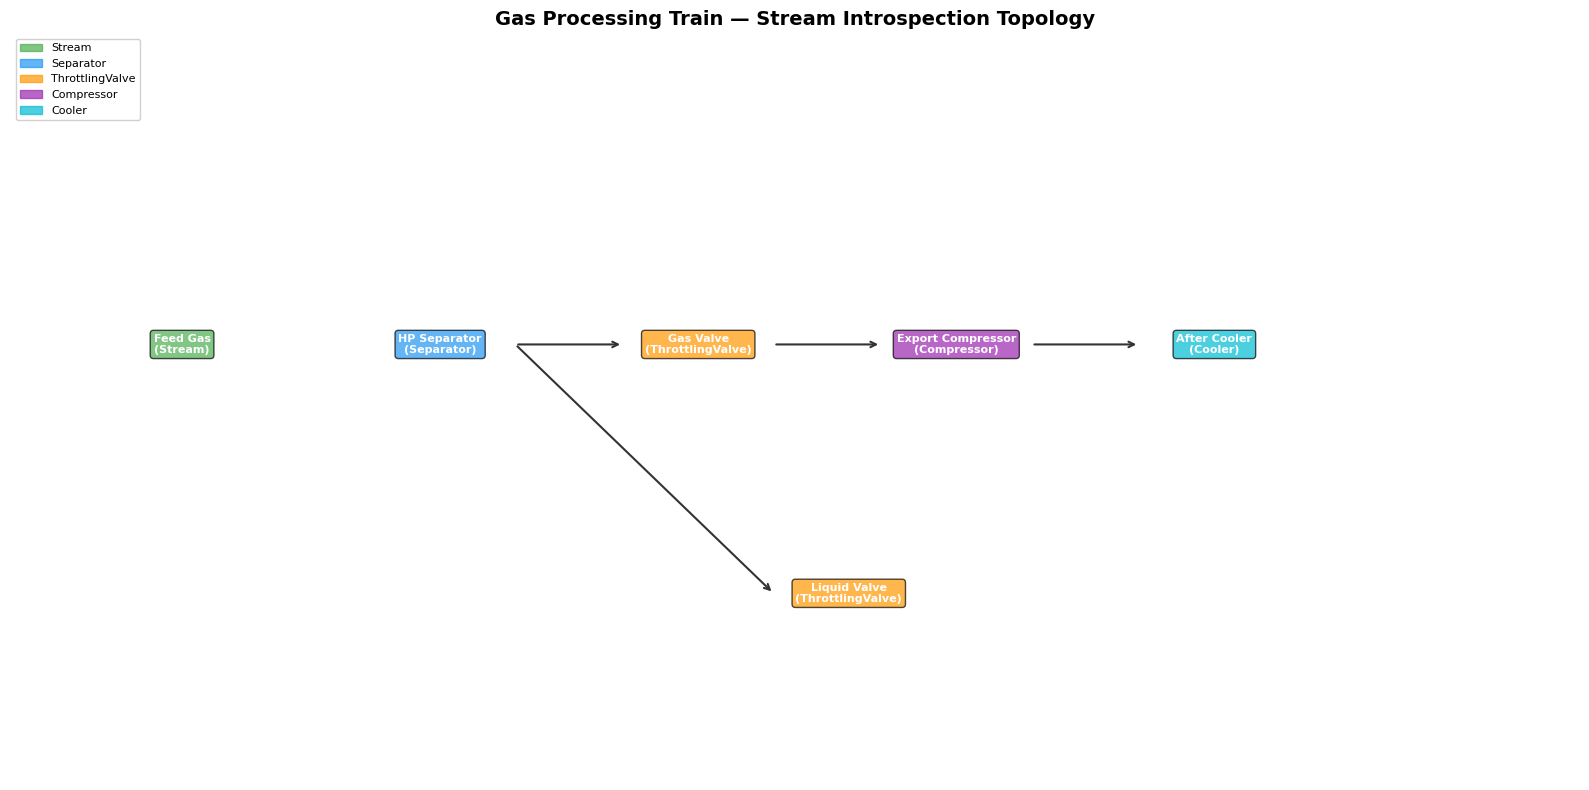

In [21]:
# Visualize the process flowsheet as a directed graph

def draw_process_flowsheet(process, title="Process Flowsheet"):
    """Draw a process flowsheet diagram using matplotlib."""
    units = list(process.getUnitOperations())
    n = len(units)

    # Assign colors by equipment type
    type_colors = {
        'Stream': '#4CAF50',
        'Separator': '#2196F3',
        'ThreePhaseSeparator': '#2196F3',
        'ThrottlingValve': '#FF9800',
        'Compressor': '#9C27B0',
        'Cooler': '#00BCD4',
        'Heater': '#F44336',
        'Mixer': '#795548',
        'Splitter': '#607D8B',
    }

    fig, ax = plt.subplots(figsize=(16, 8))

    # Position units in a flow layout
    # Simple layout: main gas path horizontal, branches below
    positions = {}
    x = 0
    y_main = 0.6
    y_branch = 0.2

    for i, unit in enumerate(units):
        name = str(unit.getName())
        unit_type = simple_class_name(unit)

        if 'Liquid' in name:
            # Branch equipment below
            positions[name] = (x - 0.5, y_branch)
        else:
            positions[name] = (x, y_main)
            x += 1.2

    # Draw equipment boxes
    for unit in units:
        name = str(unit.getName())
        unit_type = simple_class_name(unit)
        color = type_colors.get(unit_type, '#9E9E9E')
        px, py = positions[name]

        bbox = dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7, edgecolor='black')
        ax.text(px, py, f"{name}\n({unit_type})", ha='center', va='center',
                fontsize=8, fontweight='bold', color='white', bbox=bbox)

    # Draw edges from stream introspection
    for unit in units:
        name = str(unit.getName())
        if name not in positions:
            continue
        px, py = positions[name]

        for out_stream in unit.getOutletStreams():
            stream_name = str(out_stream.getName())
            # Find downstream equipment
            for other_unit in units:
                other_name = str(other_unit.getName())
                if other_name == name or other_name not in positions:
                    continue
                for in_stream in other_unit.getInletStreams():
                    if in_stream == out_stream:
                        ox, oy = positions[other_name]
                        ax.annotate('', xy=(ox - 0.35, oy), xytext=(px + 0.35, py),
                                   arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

    # Legend
    legend_patches = [mpatches.Patch(color=c, label=t, alpha=0.7)
                      for t, c in type_colors.items() if any(
                          simple_class_name(u) == t for u in units)]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=8, framealpha=0.9)

    ax.set_xlim(-0.8, x + 0.5)
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_process_flowsheet(process, "Gas Processing Train — Stream Introspection Topology")

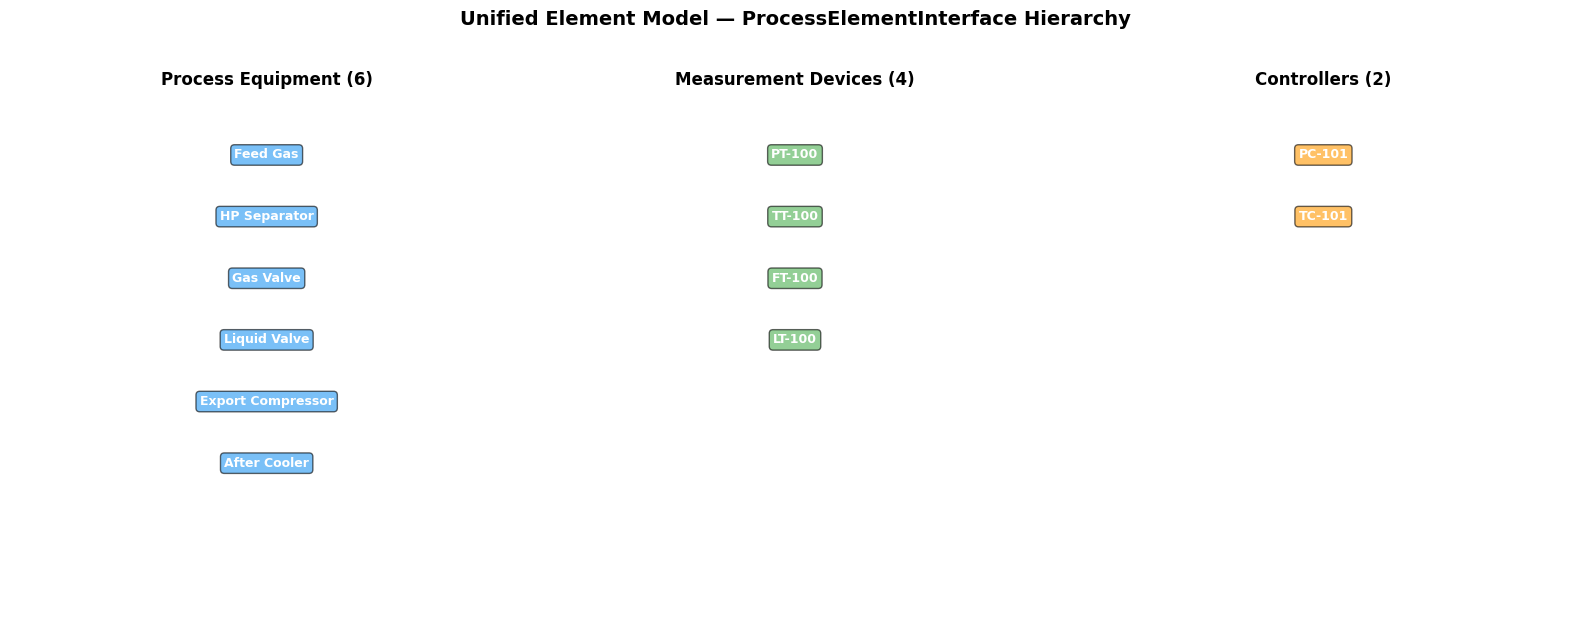

In [22]:
# Visualize the element hierarchy — equipment, instruments, controllers

def draw_element_hierarchy(process):
    """Visualize all process elements organized by type."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))

    all_elements = list(process.getAllElements())

    equipment_list = []
    measurement_list = []
    controller_list = []

    for elem in all_elements:
        name = str(elem.getName())
        if isinstance(elem, MeasurementDeviceInterface):
            measurement_list.append(name)
        elif isinstance(elem, ControllerDeviceInterface):
            controller_list.append(name)
        elif isinstance(elem, ProcessEquipmentInterface):
            equipment_list.append(name)

    categories = [
        ('Process Equipment', equipment_list, '#2196F3'),
        ('Measurement Devices', measurement_list, '#4CAF50'),
        ('Controllers', controller_list, '#FF9800'),
    ]

    for ax, (title, items, color) in zip(axes, categories):
        ax.set_title(f"{title} ({len(items)})", fontsize=12, fontweight='bold')
        for i, name in enumerate(items):
            y = 1.0 - (i + 1) * 0.12
            bbox = dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.6)
            ax.text(0.5, y, name, ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white', bbox=bbox,
                    transform=ax.transAxes)
        ax.axis('off')

    fig.suptitle('Unified Element Model — ProcessElementInterface Hierarchy',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

draw_element_hierarchy(process)

## 4.2 Connection Analysis

Analyze the explicit connections registered on the `ProcessSystem`.
Group by connection type to show material flow, energy links, and signal wiring.

CONNECTION ANALYSIS

MATERIAL connections (5):
  Feed Gas.gas_out  -->  HP Separator.inlet
  HP Separator.gas_out  -->  Gas Valve.inlet
  HP Separator.liquid_out  -->  Liquid Valve.inlet
  Gas Valve.outlet  -->  Export Compressor.inlet
  Export Compressor.outlet  -->  After Cooler.inlet

ENERGY connections (1):
  Driver.shaft  -->  Export Compressor.shaft

SIGNAL connections (1):
  PT-100.output  -->  PC-101.input


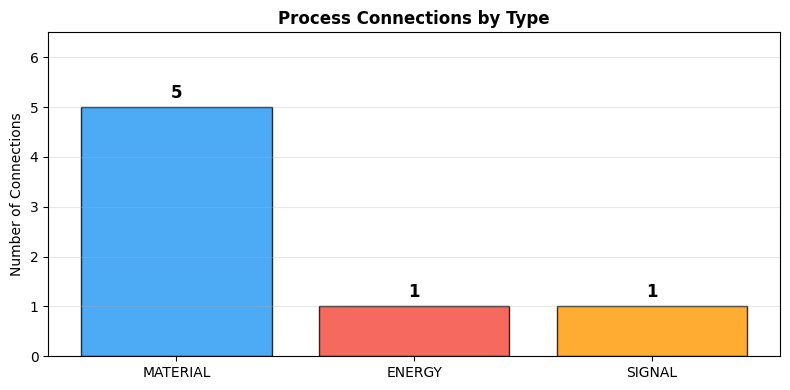

In [23]:
# Analyze connections by type
connections = list(process.getConnections())

material_conns = []
energy_conns = []
signal_conns = []

for conn in connections:
    conn_type = str(conn.getType())
    info = {
        'source': str(conn.getSourceEquipment()),
        'source_port': str(conn.getSourcePort()),
        'target': str(conn.getTargetEquipment()),
        'target_port': str(conn.getTargetPort()),
    }
    if 'MATERIAL' in conn_type:
        material_conns.append(info)
    elif 'ENERGY' in conn_type:
        energy_conns.append(info)
    elif 'SIGNAL' in conn_type:
        signal_conns.append(info)

print("=" * 70)
print("CONNECTION ANALYSIS")
print("=" * 70)

print(f"\nMATERIAL connections ({len(material_conns)}):")
for c in material_conns:
    print(f"  {c['source']}.{c['source_port']}  -->  {c['target']}.{c['target_port']}")

print(f"\nENERGY connections ({len(energy_conns)}):")
for c in energy_conns:
    print(f"  {c['source']}.{c['source_port']}  -->  {c['target']}.{c['target_port']}")

print(f"\nSIGNAL connections ({len(signal_conns)}):")
for c in signal_conns:
    print(f"  {c['source']}.{c['source_port']}  -->  {c['target']}.{c['target_port']}")

# Summary bar chart
fig, ax = plt.subplots(figsize=(8, 4))
types = ['MATERIAL', 'ENERGY', 'SIGNAL']
counts = [len(material_conns), len(energy_conns), len(signal_conns)]
colors = ['#2196F3', '#F44336', '#FF9800']
bars = ax.bar(types, counts, color=colors, alpha=0.8, edgecolor='black')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Number of Connections')
ax.set_title('Process Connections by Type', fontweight='bold')
ax.set_ylim(0, max(counts) + 1.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 Summary Dashboard

Final overview combining process results, topology, and instrumentation.

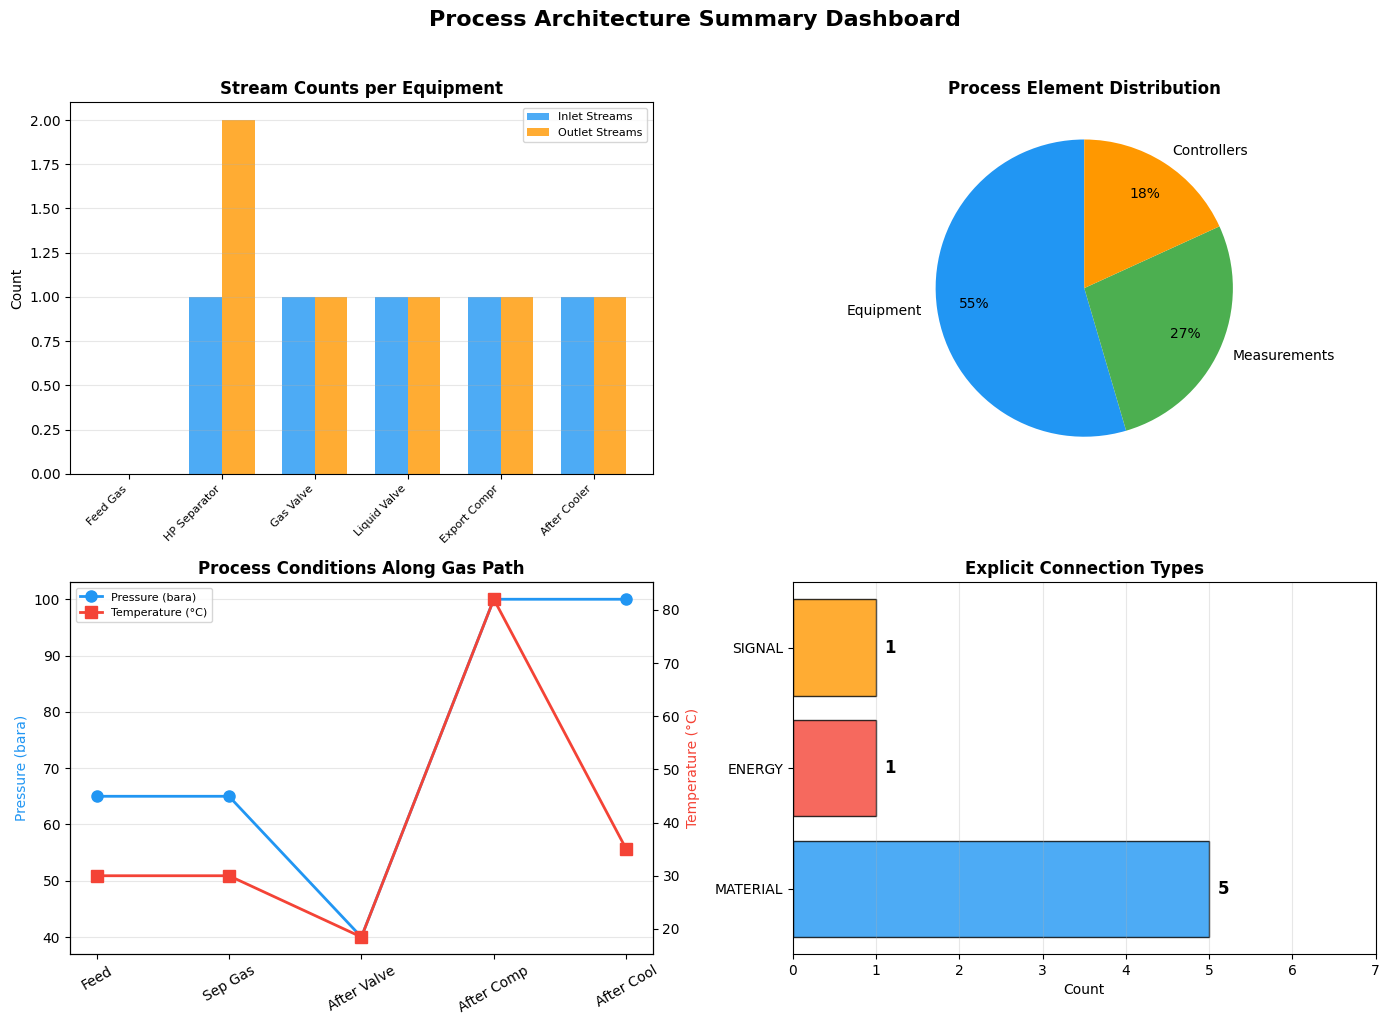

In [24]:
# Summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Equipment stream counts ---
ax1 = axes[0, 0]
unit_names = []
inlet_counts = []
outlet_counts = []

for row in topo:
    unit_names.append(row['Equipment'])
    inlet_counts.append(row['Inlet Count'])
    outlet_counts.append(row['Outlet Count'])

x_pos = np.arange(len(unit_names))
width = 0.35
ax1.bar(x_pos - width/2, inlet_counts, width, label='Inlet Streams', color='#2196F3', alpha=0.8)
ax1.bar(x_pos + width/2, outlet_counts, width, label='Outlet Streams', color='#FF9800', alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([n[:12] for n in unit_names], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Count')
ax1.set_title('Stream Counts per Equipment', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Element type distribution ---
ax2 = axes[0, 1]
elem_counts = [len(equipment), len(measurements), len(controllers)]
elem_labels = ['Equipment', 'Measurements', 'Controllers']
elem_colors = ['#2196F3', '#4CAF50', '#FF9800']
wedges, texts, autotexts = ax2.pie(elem_counts, labels=elem_labels, colors=elem_colors,
                                     autopct='%1.0f%%', startangle=90, pctdistance=0.75)
ax2.set_title('Process Element Distribution', fontweight='bold')

# --- Plot 3: Key process conditions ---
ax3 = axes[1, 0]
conditions = {
    'Feed': (feed.getPressure(), feed.getTemperature() - 273.15),
    'Sep Gas': (hp_sep.getGasOutStream().getPressure(),
                hp_sep.getGasOutStream().getTemperature() - 273.15),
    'After Valve': (gas_valve.getOutletStream().getPressure(),
                    gas_valve.getOutletStream().getTemperature() - 273.15),
    'After Comp': (compressor.getOutletStream().getPressure(),
                   compressor.getOutletStream().getTemperature() - 273.15),
    'After Cool': (cooler.getOutletStream().getPressure(),
                   cooler.getOutletStream().getTemperature() - 273.15),
}

labels = list(conditions.keys())
pressures = [conditions[k][0] for k in labels]
temperatures = [conditions[k][1] for k in labels]

ax3_twin = ax3.twinx()
line1, = ax3.plot(labels, pressures, 'o-', color='#2196F3', linewidth=2, markersize=8, label='Pressure (bara)')
line2, = ax3_twin.plot(labels, temperatures, 's-', color='#F44336', linewidth=2, markersize=8, label='Temperature (°C)')
ax3.set_ylabel('Pressure (bara)', color='#2196F3')
ax3_twin.set_ylabel('Temperature (°C)', color='#F44336')
ax3.set_title('Process Conditions Along Gas Path', fontweight='bold')
ax3.tick_params(axis='x', rotation=30)
ax3.legend(handles=[line1, line2], loc='upper left', fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# --- Plot 4: Connection type summary ---
ax4 = axes[1, 1]
conn_types = ['MATERIAL', 'ENERGY', 'SIGNAL']
conn_counts = [len(material_conns), len(energy_conns), len(signal_conns)]
conn_colors = ['#2196F3', '#F44336', '#FF9800']
bars = ax4.barh(conn_types, conn_counts, color=conn_colors, alpha=0.8, edgecolor='black')
for bar, count in zip(bars, conn_counts):
    ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(count), ha='left', va='center', fontweight='bold', fontsize=12)
ax4.set_xlabel('Count')
ax4.set_title('Explicit Connection Types', fontweight='bold')
ax4.set_xlim(0, max(conn_counts) + 2)
ax4.grid(axis='x', alpha=0.3)

plt.suptitle('Process Architecture Summary Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Summary

This notebook demonstrated the complete NeqSim process architecture:

## New Architecture Features

| Feature | API | Purpose |
|---------|-----|---------|
| **Stream Introspection** | `getInletStreams()` / `getOutletStreams()` | Walk flowsheet programmatically |
| **Named Controllers** | `addController(tag, ctrl)` / `getController(tag)` | Multi-loop equipment control |
| **Explicit Connections** | `process.connect(src, tgt, type)` | Typed metadata for P&ID |
| **Unified Elements** | `process.getAllElements()` / `ProcessElementInterface` | Query all equipment + instruments |
| **MultiPortEquipment** | Base class for multi-inlet/outlet | Manifolds, HX networks |

## DEXPI Integration Stack

| Class | Purpose |
|-------|---------|
| `DexpiXmlWriter` | Export ProcessSystem to DEXPI XML (with instruments) |
| `DexpiXmlReader` | Import DEXPI XML into ProcessSystem |
| `DexpiSimulationBuilder` | Fluent builder for DEXPI import with auto-instrumentation |
| `DexpiTopologyResolver` | Parse DEXPI graph topology (equipment + edges) |
| `DexpiEquipmentFactory` | Map DEXPI classes to NeqSim equipment |
| `DexpiMappingLoader` | Load DEXPI-to-NeqSim mapping tables |
| `DynamicProcessHelper` | Auto-instrument and export to DEXPI |

## Instrumentation Support

| Transmitter | Measures | Constructor |
|-------------|----------|-------------|
| `PressureTransmitter` | Stream pressure | `(name, stream)` |
| `TemperatureTransmitter` | Stream temperature | `(name, stream)` |
| `VolumeFlowTransmitter` | Volume flow rate | `(name, stream)` |
| `LevelTransmitter` | Separator liquid level | `(name, separator)` |

All features maintain full backward compatibility with existing code.

---

Continue to **Part 5** below for third-party DEXPI validation using the `pyDEXPI` library.

---
# Part 5 — Third-Party Validation with pyDEXPI

[pyDEXPI](https://github.com/DEXPI/pyDEXPI) is an independent Python library for parsing and
analysing DEXPI XML files. This section validates that NeqSim's DEXPI export is fully compatible
by loading the exported XML with `pyDEXPI`, inspecting parsed objects, building a process graph,
and plotting the result.

### What we check:
1. **ProteusSerializer** can load our XML without errors
2. All equipment parsed with correct DEXPI types (no `CustomEquipment`)
3. Valves recognized as `GlobeValve` piping components
4. PipingNetworkSegment connections resolve source/target items
5. **MLGraphLoader** builds a `networkx.DiGraph` from the model
6. Built-in `draw_process_matplotlib()` renders the DEXPI P&ID

In [25]:
# --- Export a fresh DEXPI XML specifically for pyDEXPI validation ---
# We build a small process with equipment that exercises all DEXPI element types:
# Equipment (Separator, Compressor, Cooler) and PipingComponent (GlobeValve).

from pathlib import Path

# Re-use the fluid from earlier
pydexpi_fluid = SystemSrkEos(273.15 + 30.0, 60.0)
pydexpi_fluid.addComponent("methane", 0.80)
pydexpi_fluid.addComponent("ethane", 0.10)
pydexpi_fluid.addComponent("propane", 0.05)
pydexpi_fluid.addComponent("nC10", 0.05)
pydexpi_fluid.setMixingRule("classic")

pydexpi_feed = Stream("Feed", pydexpi_fluid)
pydexpi_feed.setFlowRate(50000.0, "kg/hr")

pydexpi_sep = Separator("V-100", pydexpi_feed)
pydexpi_comp = Compressor("K-100", pydexpi_sep.getGasOutStream())
pydexpi_comp.setOutletPressure(120.0)
pydexpi_cooler = Cooler("E-100", pydexpi_comp.getOutletStream())
pydexpi_cooler.setOutTemperature(273.15 + 30.0)
pydexpi_valve = ThrottlingValve("XV-200", pydexpi_sep.getLiquidOutStream())
pydexpi_valve.setOutletPressure(10.0)

pydexpi_process = ProcessSystem()
pydexpi_process.add(pydexpi_feed)
pydexpi_process.add(pydexpi_sep)
pydexpi_process.add(pydexpi_comp)
pydexpi_process.add(pydexpi_cooler)
pydexpi_process.add(pydexpi_valve)
pydexpi_process.run()

# Export to temp file
import tempfile
pydexpi_tmpdir = tempfile.mkdtemp(prefix="neqsim_pydexpi_demo_")
pydexpi_xml_path = os.path.join(pydexpi_tmpdir, "process.dexpi.xml")
DexpiXmlWriter.write(pydexpi_process, File(pydexpi_xml_path))

print(f"DEXPI XML exported: {os.path.getsize(pydexpi_xml_path):,} bytes")
print(f"Location: {pydexpi_xml_path}")

DEXPI XML exported: 3,444 bytes
Location: C:\Users\ESOL\AppData\Local\Temp\neqsim_pydexpi_demo_uxruzeo0\process.dexpi.xml


In [26]:
# --- Load DEXPI XML with pyDEXPI and inspect the model ---
from pydexpi.loaders.proteus_serializer import ProteusSerializer

serializer = ProteusSerializer()
xml_path = Path(pydexpi_xml_path)
dexpi_model = serializer.load(xml_path.parent, xml_path.name)

print("=== DEXPI Model Inspection ===\n")

# 1. Tagged plant items (equipment & valves)
tagged_items = dexpi_model.conceptualModel.taggedPlantItems
print(f"Tagged Plant Items: {len(tagged_items)}")
for item in tagged_items:
    tag = getattr(item, 'tagName', 'N/A')
    cclass = type(item).__name__
    print(f"  • {tag:20s}  ({cclass})")

# 2. Piping network systems (connections between equipment)
piping_systems = dexpi_model.conceptualModel.pipingNetworkSystems
print(f"\nPiping Network Systems: {len(piping_systems)}")
for ps in piping_systems:
    segments = ps.pipingNetworkSegments if hasattr(ps, 'pipingNetworkSegments') else []
    print(f"  System: {getattr(ps, 'tagName', 'unnamed')} — {len(segments)} segment(s)")
    for seg in segments:
        src = getattr(seg, 'sourceItem', None)
        tgt = getattr(seg, 'targetItem', None)
        src_tag = getattr(src, 'tagName', '?') if src else '?'
        tgt_tag = getattr(tgt, 'tagName', '?') if tgt else '?'
        print(f"    {src_tag} → {tgt_tag}")

# 3. DEXPI component class mapping check
print("\n=== DEXPI Component Class Mapping ===")
for item in tagged_items:
    tag = getattr(item, 'tagName', 'N/A')
    dexpi_class = type(item).__name__
    # Check we don't have generic CustomEquipment (indicates mapping failure)
    status = "✓ Mapped" if dexpi_class != "CustomEquipment" else "✗ Generic"
    print(f"  {tag:20s}  {dexpi_class:30s}  {status}")

=== DEXPI Model Inspection ===

Tagged Plant Items: 3
  • V-100                 (Separator)
  • K-100                 (CentrifugalCompressor)
  • E-100                 (AirCoolingSystem)

Piping Network Systems: 1
  System: unnamed — 0 segment(s)

=== DEXPI Component Class Mapping ===
  V-100                 Separator                       ✓ Mapped
  K-100                 CentrifugalCompressor           ✓ Mapped
  E-100                 AirCoolingSystem                ✓ Mapped


=== DEXPI → NetworkX Graph ===
Nodes: 6
Edges: 0

Node details:
  12cd9ec2-0689-4479-8012-a2d47104eeea: {'tagName': 'V-100', 'tagNamePrefix': None, 'tagNameSequenceNumber': None, 'tagNameSuffix': None, 'equipmentDescription': None, 'designVolumeFlowRate': None, 'efficiency': None, 'upperLimitAllowableDesignPressureDrop': None, 'dexpi_class': 'Separator'}
  d6a11ed5-80e9-458c-8e62-a9dfb0e26f7a: {'tagName': 'K-100', 'tagNamePrefix': None, 'tagNameSequenceNumber': None, 'tagNameSuffix': None, 'equipmentDescription': None, 'designVolumeFlowRate': None, 'differentialPressure': None, 'designRotationalSpeed': None, 'designShaftPower': None, 'dexpi_class': 'CentrifugalCompressor'}
  c786f432-61b1-4ef8-b4b2-408969fef4af: {'tagName': 'E-100', 'tagNamePrefix': None, 'tagNameSequenceNumber': None, 'tagNameSuffix': None, 'equipmentDescription': None, 'designHeatFlowRate': None, 'designHeatTransferArea': None, 'designHeatTransferCoefficient': None, 'designPower': None, 'designRotationalSpeed': None,

C:\Users\ESOL\AppData\Local\Temp\ipykernel_24720\4142989637.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


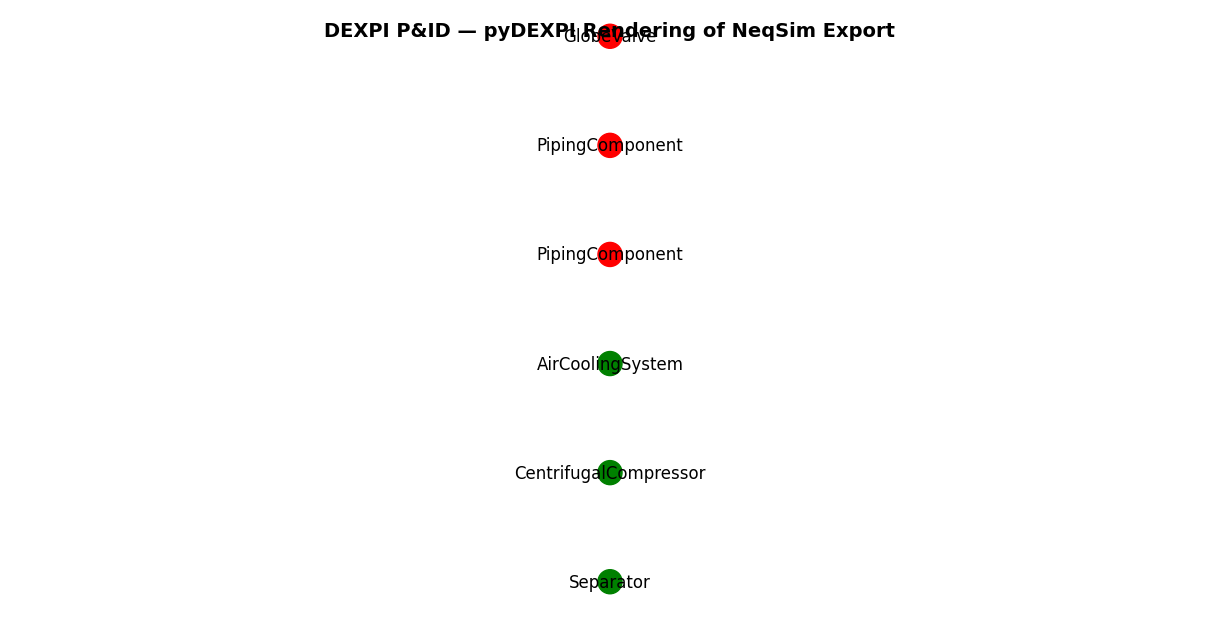

In [27]:
# --- Build a NetworkX graph from the DEXPI model and plot it ---
from pydexpi.loaders.ml_graph_loader import MLGraphLoader
import matplotlib.pyplot as plt

loader = MLGraphLoader()
dexpi_graph = loader.dexpi_to_graph(dexpi_model)

print("=== DEXPI → NetworkX Graph ===")
print(f"Nodes: {dexpi_graph.number_of_nodes()}")
print(f"Edges: {dexpi_graph.number_of_edges()}")
print()

print("Node details:")
for node_id, attrs in dexpi_graph.nodes(data=True):
    print(f"  {node_id}: {attrs}")

print("\nEdge details:")
for u, v, attrs in dexpi_graph.edges(data=True):
    print(f"  {u} → {v}: {attrs}")

# --- pyDEXPI built-in matplotlib plot ---
print("\n--- pyDEXPI Process Diagram (matplotlib) ---")
fig = loader.draw_process_matplotlib()
fig.set_size_inches(12, 6)
fig.suptitle("DEXPI P&ID — pyDEXPI Rendering of NeqSim Export", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

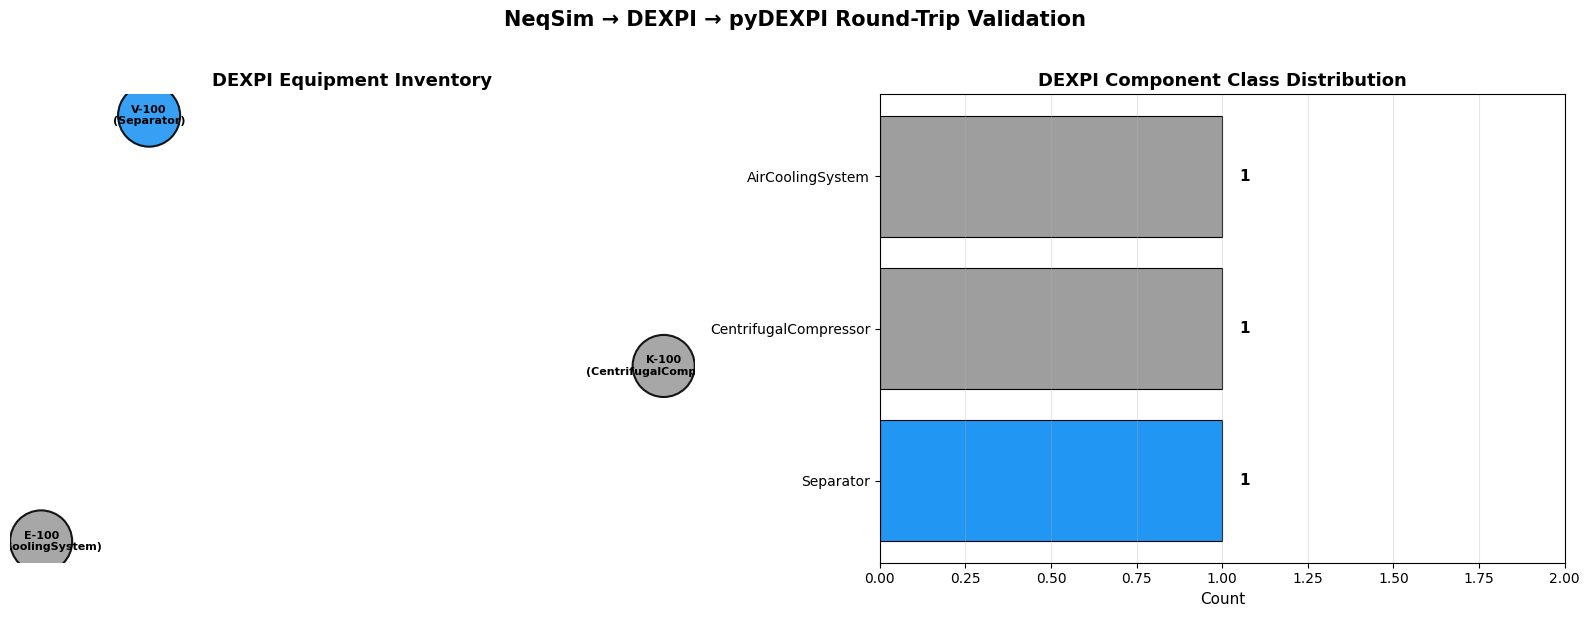


✅ pyDEXPI round-trip validation complete!


In [28]:
# --- Custom NetworkX visualization with color-coded equipment types ---
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left panel: pyDEXPI tagged items as a colored node diagram ---
ax1 = axes[0]
ax1.set_title("DEXPI Equipment Inventory", fontsize=13, fontweight="bold")

# Build a simple graph from tagged plant items
equip_graph = nx.DiGraph()
color_map = {
    "Separator": "#2196F3",        # Blue
    "Compressor": "#FF9800",       # Orange
    "HeatExchanger": "#4CAF50",    # Green
    "Cooler": "#4CAF50",           # Green (heat exchanger variant)
    "GlobeValve": "#F44336",       # Red
    "PipingComponent": "#F44336",  # Red (valve)
    "CentrifugalPump": "#9C27B0",  # Purple
}
default_color = "#9E9E9E"  # Grey

node_colors = []
node_labels = {}
for item in tagged_items:
    tag = getattr(item, 'tagName', 'Unknown')
    cclass = type(item).__name__
    equip_graph.add_node(tag, dexpi_class=cclass)
    node_labels[tag] = f"{tag}\n({cclass})"
    node_colors.append(color_map.get(cclass, default_color))

# Add edges from piping network
for ps in piping_systems:
    segments = ps.pipingNetworkSegments if hasattr(ps, 'pipingNetworkSegments') else []
    for seg in segments:
        src = getattr(seg, 'sourceItem', None)
        tgt = getattr(seg, 'targetItem', None)
        src_tag = getattr(src, 'tagName', None) if src else None
        tgt_tag = getattr(tgt, 'tagName', None) if tgt else None
        if src_tag and tgt_tag and src_tag in equip_graph and tgt_tag in equip_graph:
            equip_graph.add_edge(src_tag, tgt_tag)

pos = nx.spring_layout(equip_graph, seed=42, k=2.0)
nx.draw_networkx_nodes(equip_graph, pos, ax=ax1, node_color=node_colors,
                       node_size=2000, alpha=0.9, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(equip_graph, pos, labels=node_labels, ax=ax1,
                        font_size=8, font_weight="bold")
nx.draw_networkx_edges(equip_graph, pos, ax=ax1, edge_color="#555555",
                       arrows=True, arrowsize=20, width=2,
                       connectionstyle="arc3,rad=0.1")
ax1.set_axis_off()

# --- Right panel: DEXPI class distribution bar chart ---
ax2 = axes[1]
ax2.set_title("DEXPI Component Class Distribution", fontsize=13, fontweight="bold")

class_counts = {}
for item in tagged_items:
    cclass = type(item).__name__
    class_counts[cclass] = class_counts.get(cclass, 0) + 1

classes = list(class_counts.keys())
counts = list(class_counts.values())
bar_colors = [color_map.get(c, default_color) for c in classes]
bars = ax2.barh(classes, counts, color=bar_colors, edgecolor="black", linewidth=0.8)
ax2.set_xlabel("Count", fontsize=11)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             str(count), va="center", fontsize=11, fontweight="bold")
ax2.set_xlim(0, max(counts) + 1)
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("NeqSim → DEXPI → pyDEXPI Round-Trip Validation", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ pyDEXPI round-trip validation complete!")